# Task 4 — Pick the right chart, five times
Dataset: `mpg.csv`, 398 cars from 1970-1982. `horsepower` missing for 6 cars.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# ---- House palette (colour-blind safe, same as the lecture notebook) ----
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
GREEN, VIOLET, RED = "#008300", "#4a3aa7", "#e34948"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 14, "axes.labelsize": 10, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT, "legend.frameon": False,
    "legend.fontsize": 10, "lines.linewidth": 2, "font.size": 11,
    "savefig.dpi": 150, "savefig.bbox": "tight",
})

def save(fig, name):
    fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE)

def note(ax, text, y=-0.2):
    """Footnote under a chart - used to say what was excluded."""
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)

In [2]:
m = pd.read_csv(DATA / "mpg.csv")
print(m.shape, "| missing horsepower:", int(m.horsepower.isna().sum()))
m.head()

(398, 9) | missing horsepower: 6


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## Q1 — Did cars get more fuel-efficient between 1970 and 1982?
Line chart: year is ordered and I'm tracking one number (mean mpg) over it.

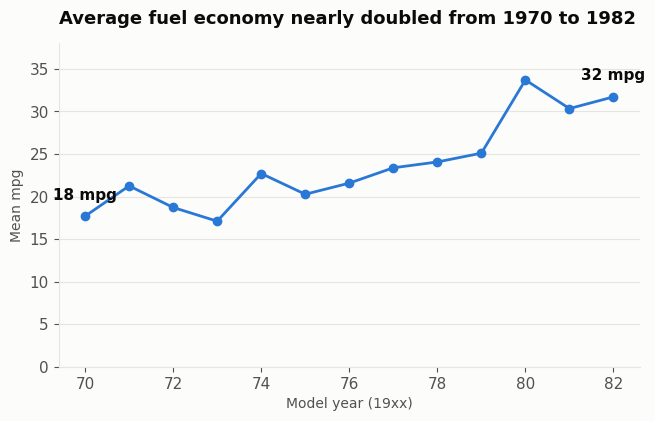

In [3]:
yearly = m.groupby("model_year").mpg.mean()
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(yearly.index, yearly.values, color=BLUE, marker="o", markersize=6, zorder=3)
for yr in (70, 82):
    ax.annotate(f"{yearly[yr]:.0f} mpg", (yr, yearly[yr]), textcoords="offset points",
                xytext=(0, 12), ha="center", fontweight="bold", color=INK)
ax.set_title("Average fuel economy nearly doubled from 1970 to 1982")
ax.set_xlabel("Model year (19xx)"); ax.set_ylabel("Mean mpg")
ax.set_ylim(0, 38)
ax.xaxis.grid(False)
save(fig, "t4_q1_line")
plt.show()

Yes, clearly — average mpg went from about 18 to about 32, with most of the jump after 1979 (likely the CAFE fuel economy standards and the 1979 oil shock, though the data itself doesn't say why).

## Q2 — Do American, European and Japanese cars differ in fuel efficiency?
Bar chart: three separate, unordered categories, comparing one number each.

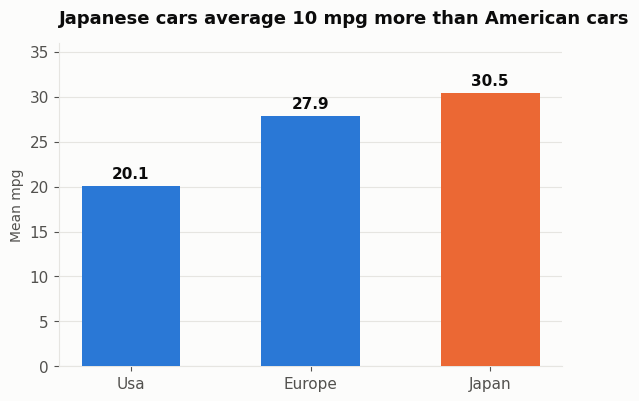

In [4]:
by_origin = m.groupby("origin").mpg.mean().sort_values()
fig, ax = plt.subplots(figsize=(6.5, 4.2))
colours = [BLUE if o != by_origin.index[-1] else ORANGE for o in by_origin.index]
bars = ax.bar(by_origin.index.str.title(), by_origin.values, color=colours, width=0.55, zorder=3)
for bar, v in zip(bars, by_origin.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.8, f"{v:.1f}", ha="center", fontweight="bold", color=INK)
ax.set_title("Japanese cars average 10 mpg more than American cars")
ax.set_ylabel("Mean mpg"); ax.set_ylim(0, 36)
ax.xaxis.grid(False); ax.set_axisbelow(True)
save(fig, "t4_q2_bar")
plt.show()

Yes — Japan averages about 30.5 mpg, Europe about 27.9, the US about 20.1. US cars are the least efficient by a wide margin.

## Q3 — Relationship between weight and fuel efficiency
Scatter plot: two numeric variables, looking for whether they move together.

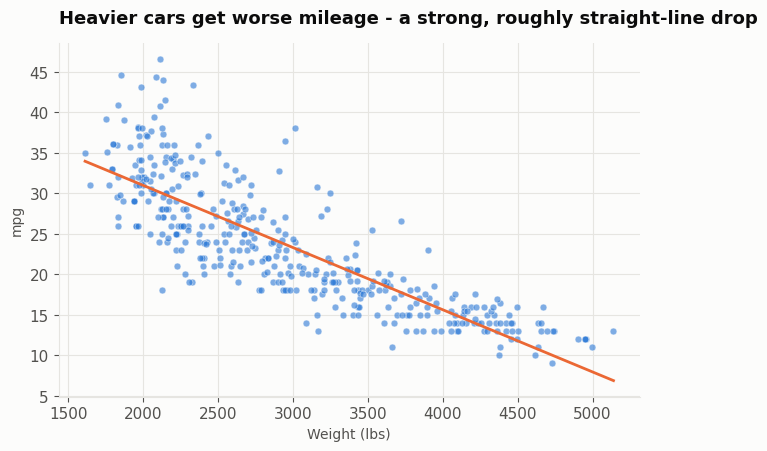

correlation: -0.83


In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.scatter(m.weight, m.mpg, s=24, color=BLUE, alpha=0.6, edgecolor=SURFACE, linewidth=0.5, zorder=3)
cfit = np.polyfit(m.weight, m.mpg, 1)
xs = np.array([m.weight.min(), m.weight.max()])
ax.plot(xs, cfit[0]*xs + cfit[1], color=ORANGE, linewidth=2, zorder=4)
ax.set_title("Heavier cars get worse mileage - a strong, roughly straight-line drop")
ax.set_xlabel("Weight (lbs)"); ax.set_ylabel("mpg")
save(fig, "t4_q3_scatter")
plt.show()
print("correlation:", round(m.weight.corr(m.mpg), 2))

Strongly negative — correlation of about -0.83. As weight goes up, mpg goes down in a fairly straight line, though it bends down a bit faster at the low-weight end.

## Q4 — How are cylinder counts distributed?
Bar chart, not a histogram: cylinder count only takes a few discrete values (3,4,5,6,8), it isn't a
continuous measurement, so there's no reason for the bars to touch.

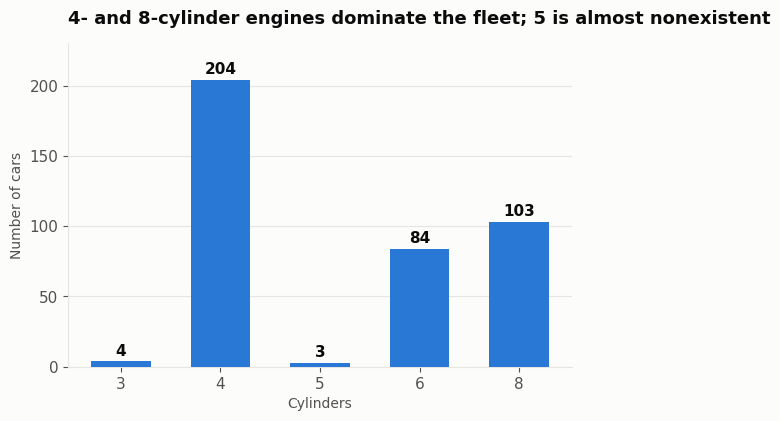

In [6]:
cyl = m.cylinders.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.bar(cyl.index.astype(str), cyl.values, color=BLUE, width=0.6, zorder=3)
for i, v in enumerate(cyl.values):
    ax.text(i, v + 4, str(v), ha="center", fontweight="bold", color=INK)
ax.set_title("4- and 8-cylinder engines dominate the fleet; 5 is almost nonexistent")
ax.set_xlabel("Cylinders"); ax.set_ylabel("Number of cars")
ax.set_ylim(0, 230)
ax.xaxis.grid(False); ax.set_axisbelow(True)
save(fig, "t4_q4_bar")
plt.show()

4-cylinder cars are over half the fleet (204 of 398), 8-cylinder are the second biggest group (103). 3- and 5-cylinder are essentially rounding errors (4 and 3 cars).

## Q5 — Is the efficiency gain explained by cars getting lighter?
Line chart again, since it's the same "over time" structure as Q1, but now with two lines so the two
trends can be compared directly. I'm not using two y-axes for this (the course rule against it) — I
index both series to their 1970 value so they share one axis, which is honest and still shows whether
they move together.

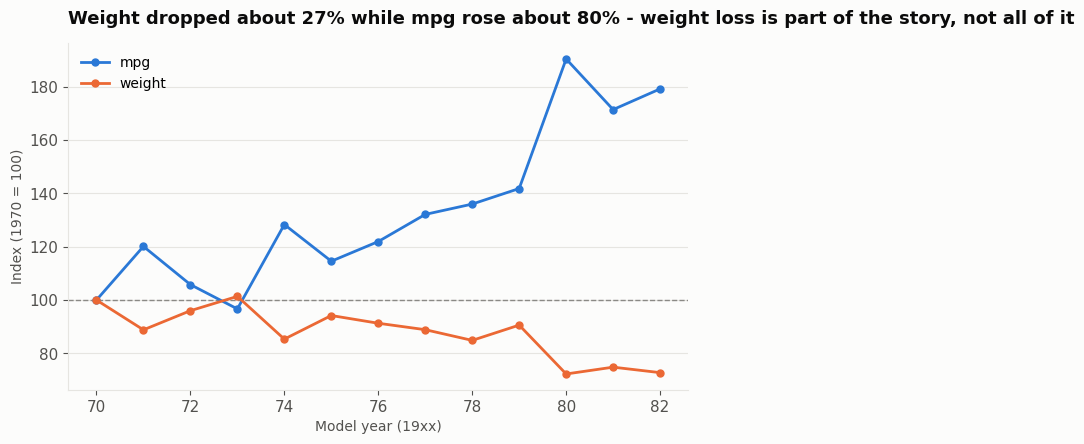

In [7]:
idx = pd.DataFrame({
    "mpg": yearly / yearly.loc[70] * 100,
    "weight": m.groupby("model_year").weight.mean() / m.groupby("model_year").weight.mean().loc[70] * 100,
})
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(idx.index, idx.mpg, color=BLUE, marker="o", markersize=5, label="mpg", zorder=3)
ax.plot(idx.index, idx.weight, color=ORANGE, marker="o", markersize=5, label="weight", zorder=3)
ax.axhline(100, color=INK_MUTED, linewidth=1, linestyle="--")
ax.set_title("Weight dropped about 27% while mpg rose about 80% - weight loss is part of the story, not all of it")
ax.title.set_fontsize(12)
ax.set_xlabel("Model year (19xx)"); ax.set_ylabel("Index (1970 = 100)")
ax.xaxis.grid(False); ax.legend(loc="upper left")
save(fig, "t4_q5_index")
plt.show()

Partly. Weight dropped from about 3,373 lbs to about 2,454 lbs — a real drop, about 27% — but mpg
rose about 80% over the same years. If weight were the whole explanation the two lines would move by
roughly the same percentage, and they don't; mpg outpaces the weight drop, especially after 1979. So
lighter cars are part of the answer, but something else changed too — probably engine technology
(smaller displacement, better combustion) given the question only gives us the two variables.

## Which chart is weakest, and the redo
Q4's bar chart is fine on its own but it's the weakest of the five because it's the least
*interesting* — it answers a simple counting question and nothing else. A more useful version of "how
are cylinders distributed" is whether that distribution changed over time, since the Q1/Q5 story is
really about the 1979-82 period.

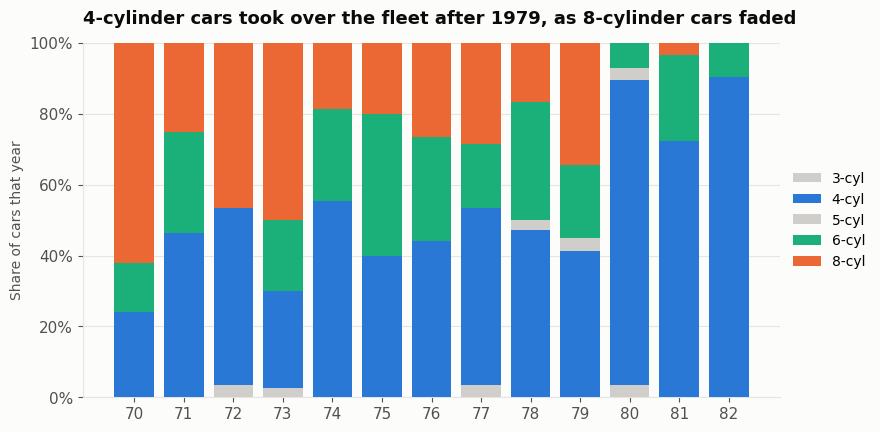

In [8]:
ct = pd.crosstab(m.model_year, m.cylinders, normalize="index") * 100
fig, ax = plt.subplots(figsize=(9, 4.6))
bottom = np.zeros(len(ct))
cyl_colours = {3: QUIET, 4: BLUE, 5: QUIET, 6: AQUA, 8: ORANGE}
for c in ct.columns:
    ax.bar(ct.index.astype(str), ct[c], bottom=bottom, color=cyl_colours[c], label=f"{c}-cyl", zorder=3)
    bottom += ct[c].values
ax.set_title("4-cylinder cars took over the fleet after 1979, as 8-cylinder cars faded")
ax.set_ylabel("Share of cars that year"); ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(lambda v, p: f"{v:.0f}%")
ax.xaxis.grid(False)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
save(fig, "t4_q4_redo_stacked")
plt.show()

Changed: a single-year bar chart became a stacked bar across all 13 years, which connects back to
Q1 and Q5 instead of sitting alone. It shows the same underlying shift as the mpg/weight story — a
move toward smaller engines — but at the engine level instead of the weight level.